In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder , OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [66]:
# load dataset
data = pd.read_csv('/content/cropdata_updated.csv')
# data analysis
data.head()
data.isnull().sum()
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


,MOI,temp,humidity,result
count,16411.000000,16411.000000,16411.000000,16411.000000
mean,43.695387,28.832612,63.487752,0.516178
std,27.160264,9.701465,22.630965,0.621691
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,20.000000,44.000000,0.000000
50%,41.000000,28.000000,69.200000,0.000000
75%,64.000000,37.000000,84.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


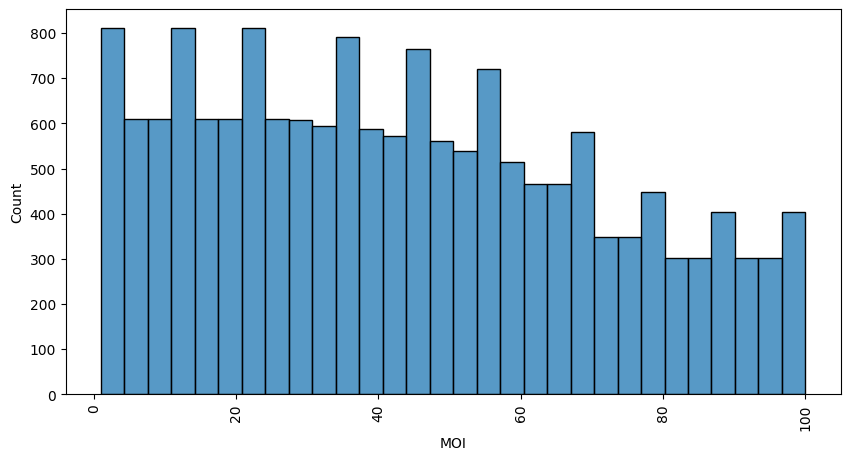

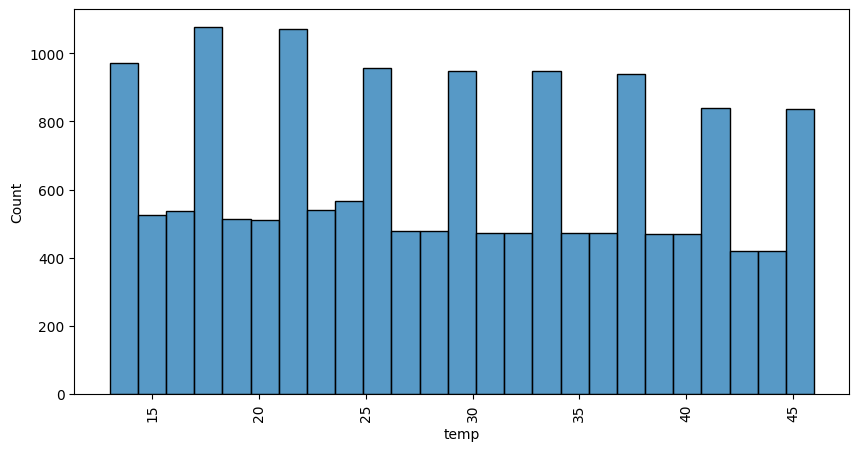

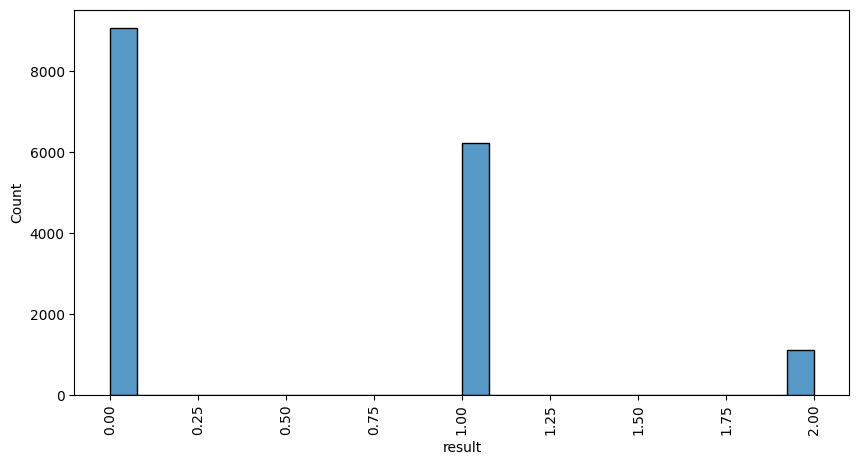

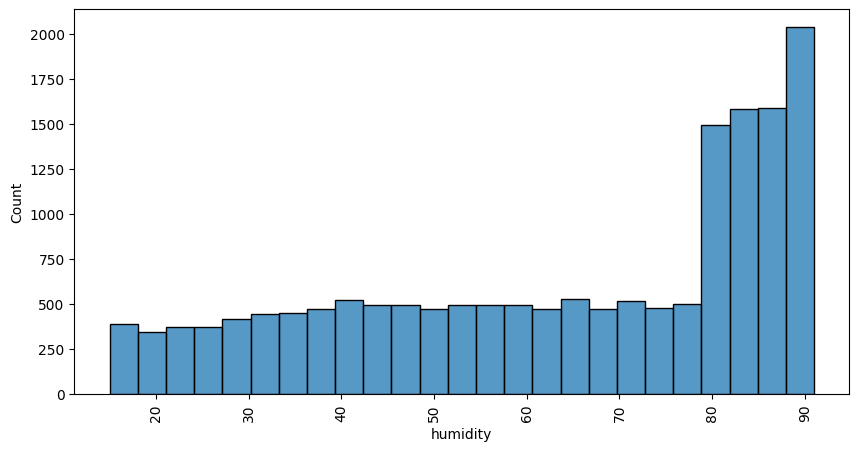

In [67]:
# data Visualization
numerical_columns = ['MOI','temp','result','humidity']
catergorial_columns = ['crop ID','soil_type','Seedling Stage']
for col in numerical_columns :
  plt.figure(figsize=(10,5))
  sns.histplot(x = data[col])
  plt.xticks(rotation=90)
  plt.show()

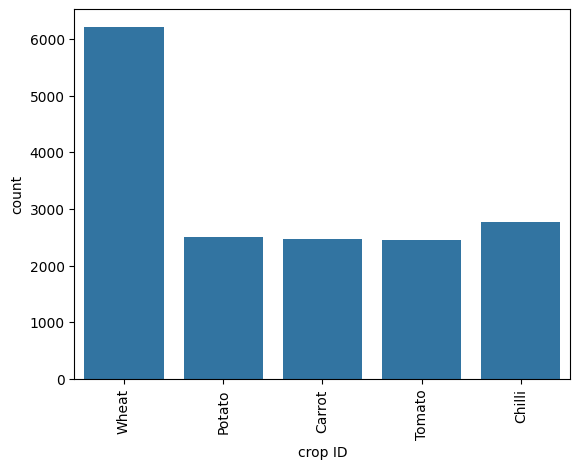

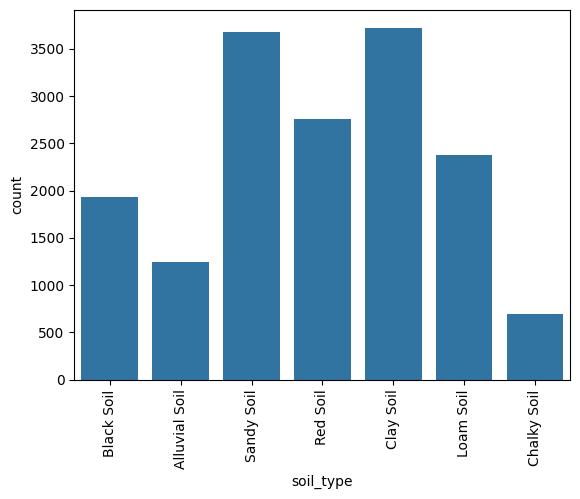

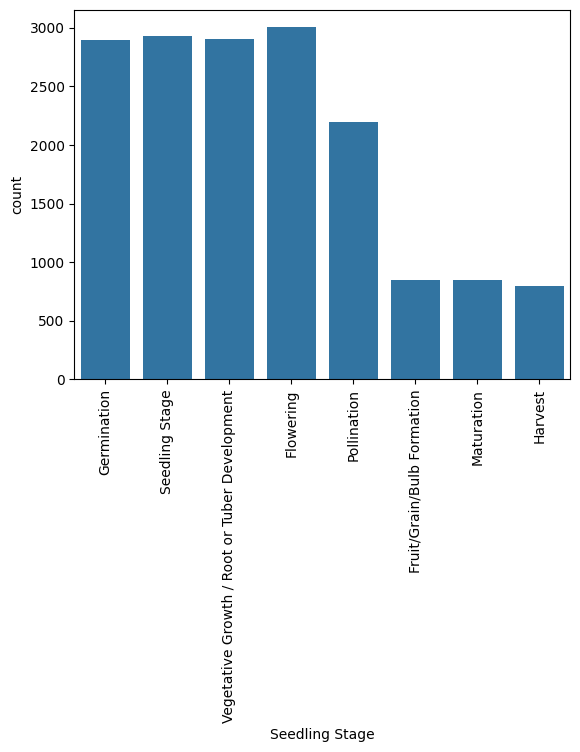

In [68]:
for col in  catergorial_columns:
  sns.countplot(x=data[col])
  plt.xticks(rotation=90)
  plt.show()

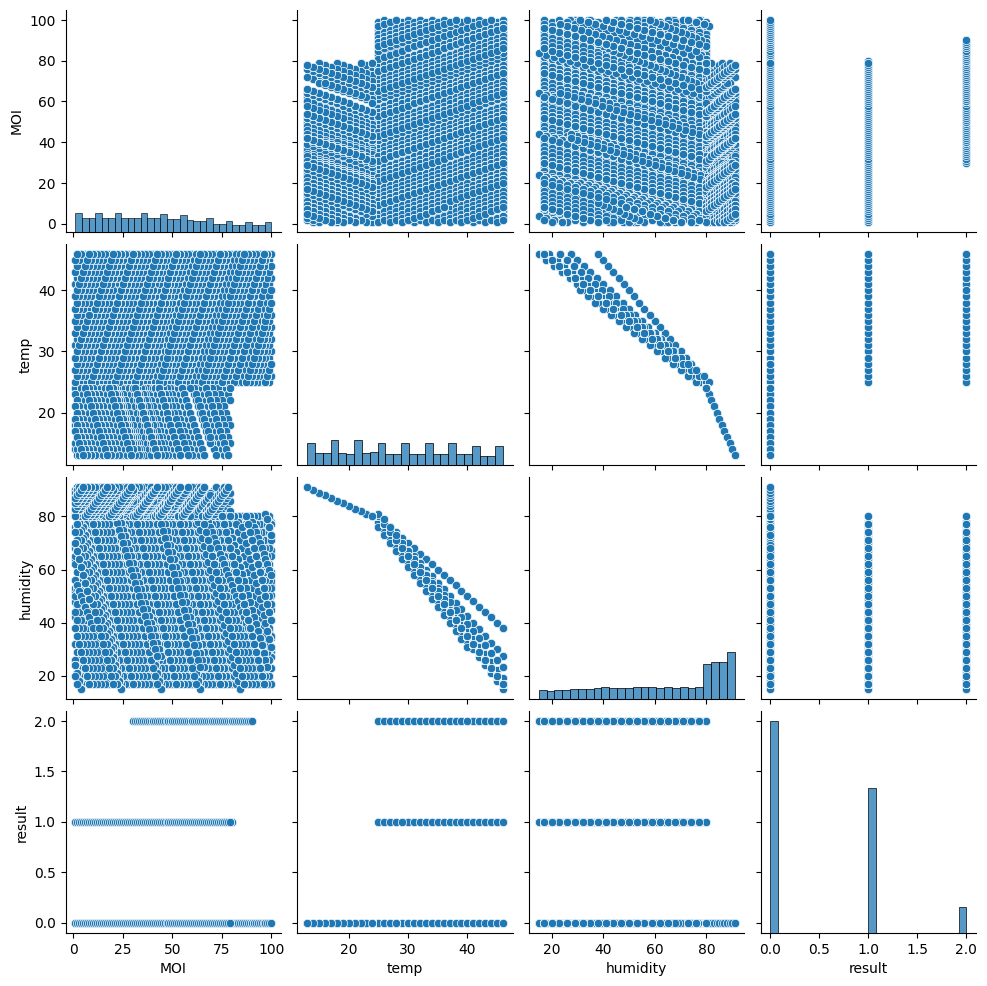

In [69]:
sns.pairplot(data)
plt.show()

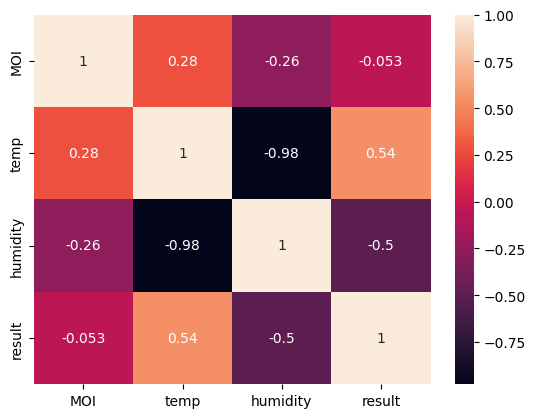

In [70]:
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.show()

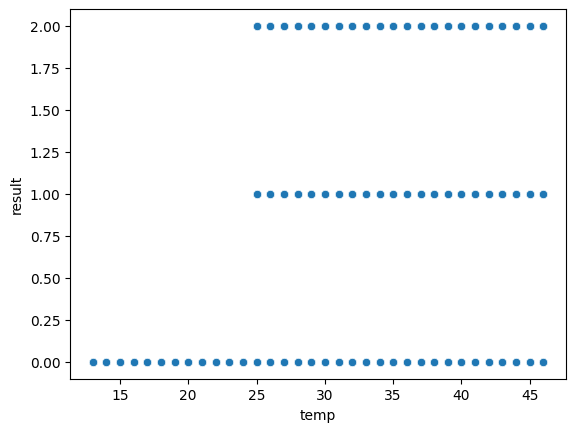

In [71]:
sns.scatterplot(x=data['temp'],y=data['result'])
plt.show()

In [72]:
# Feature engineering
data.columns

Index(['crop ID', 'soil_type', 'Seedling Stage', 'MOI', 'temp', 'humidity',
       'result'],
      dtype='object')

In [73]:
data['Fungal_Risk'] = data['MOI'] * data['temp']
data['Fungal_Risk']
data['Sauna Effect'] = data['temp'] * data['humidity']
data['Sauna Effect']


,Sauna Effect
0,2000.0
1,2002.0
2,1998.0
3,1988.0
4,1972.0
...,...
16406,1408.0
16407,1335.0
16408,1260.0
16409,1183.0


In [74]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Re-split data to ensure engineered features are included in x_train/x_test
x = data.drop('result', axis=1)
y = data['result']
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Define feature columns based on x_train
numerical_features = ['MOI','temp','humidity','Fungal_Risk','Sauna Effect']
categorical_features = ['crop ID', 'soil_type', 'Seedling Stage'] # Treat these as categorical for OneHotEncoder

# Preprocessing Pipelines
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep any other columns not explicitly transformed
)

# Define the full pipeline: preprocessor + model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestClassifier())
])

# Fit the full pipeline on training data
full_pipeline.fit(x_train,y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MOI', 'temp', 'humidity',
                                                   'Fungal_Risk',
                                                   'Sauna Effect']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['crop ID', 'soil_type',
                                                   'Seedling Stage'])])),
                ('regressor', RandomForestClassifier())])

In [75]:
test_accuracy = full_pipeline.predict(x_test)
train_accuracy = full_pipeline.predict(x_train)
r2_testing = r2_score(y_test,test_accuracy)
r2_training = r2_score(y_train,train_accuracy)
mae = mean_absolute_error(y_test,test_accuracy)

print(f"R2 Score for Testing Data: {r2_testing}")
print(f"R2 Score for Training Data: {r2_training}")
print(f"Mean Absolute Error: {mae}")


R2 Score for Testing Data: 0.946595749433329
R2 Score for Training Data: 1.0
Mean Absolute Error: 0.01370697532744441


In [76]:
from sklearn.model_selection import RandomizedSearchCV

para_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1,2,4]
}

random_Search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=para_grid,
    n_iter=10,
    cv=5,
    verbose=2,
    random_state=42,
)

random_Search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END regressor__max_depth=20, regressor__min_samples_leaf=1, regressor__min_samples_split=5, regressor__n_estimators=100; total time=   0.7s
[CV] END regressor__max_depth=20, regressor__min_samples_leaf=1, regressor__min_samples_split=5, regressor__n_estimators=100; total time=   0.7s
[CV] END regressor__max_depth=20, regressor__min_samples_leaf=1, regressor__min_samples_split=5, regressor__n_estimators=100; total time=   0.7s
[CV] END regressor__max_depth=20, regressor__min_samples_leaf=1, regressor__min_samples_split=5, regressor__n_estimators=100; total time=   0.9s
[CV] END regressor__max_depth=20, regressor__min_samples_leaf=1, regressor__min_samples_split=5, regressor__n_estimators=100; total time=   0.8s
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   0.8s
[CV] END regressor__max_depth=10, regressor__min_samples_leaf=1, regr

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['MOI',
                                                                                'temp',
                                                                                'humidity',
                                                                                'Fungal_Risk',
                                                                                'Sauna '
                                                                                'Effect']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['crop '
                                                                                'ID',
                                                                                'soil_type',
                                                                                'Seedling '
                                                                                'Stage'])])),
                                             ('regressor',
                                              RandomForestClassifier())]),
                   param_distributions={'regressor__max_depth': [10, 20, 30],
                                        'regressor__min_samples_leaf': [1, 2,
                                                                        4],
                                        'regressor__min_samples_split': [2, 5,
                                                                         10],
                                        'regressor__n_estimators': [100, 200,
                                                                    300]},
                   random_state=42, verbose=2)

In [84]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

# Preprocess the training and test features using the already fitted preprocessor
X_train_processed_ann = preprocessor.transform(x_train)
X_test_processed_ann = preprocessor.transform(x_test) # Use x_test here for features

# Encode target variables
y_train_encoded = to_categorical(y_train, num_classes=3)
y_test_encoded = to_categorical(y_test, num_classes=3) # Encode y_test as well

model = Sequential([
    Dense(16,activation='relu',input_shape=(X_train_processed_ann.shape[1],)), # Use processed shape
    Dense(8,activation='relu'),
    Dense(3,activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(X_train_processed_ann, y_train_encoded, # Use processed features and encoded target
                    validation_data=(X_test_processed_ann, y_test_encoded), # Correct validation data
                    epochs=30 , batch_size=32)

Epoch 1/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7978 - loss: 0.5139 - val_accuracy: 0.8879 - val_loss: 0.2947
Epoch 2/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8940 - loss: 0.2689 - val_accuracy: 0.9041 - val_loss: 0.2381
Epoch 3/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9082 - loss: 0.2307 - val_accuracy: 0.9132 - val_loss: 0.2112
Epoch 4/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9190 - loss: 0.2042 - val_accuracy: 0.9232 - val_loss: 0.1859
Epoch 5/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9288 - loss: 0.1788 - val_accuracy: 0.9373 - val_loss: 0.1612
Epoch 6/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9381 - loss: 0.1559 - val_accuracy: 0.9430 - val_loss: 0.1417
Epoch 7/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9442 - loss: 0.1369 - val_accuracy: 0.9473 - val_loss: 0.1264
Epoch 8/30
411/411 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9513 - loss: 0.1229 - val_accuracy: 0.

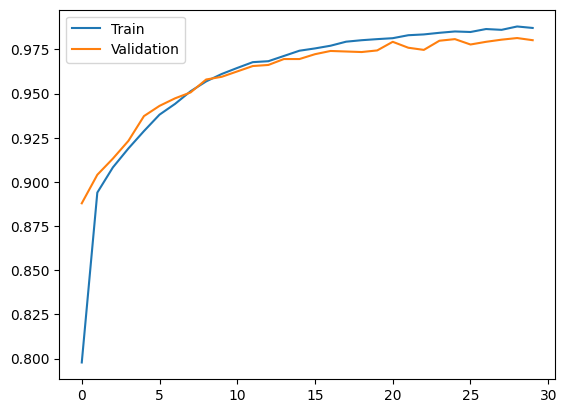

In [85]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train', 'Validation'], loc='upper left')